# **1️⃣ Dataset Download & Load**

In [1]:
import kagglehub
import os
import pandas as pd

# Download dataset
path = kagglehub.dataset_download("pooriamst/metro-interstate-traffic-volume")
print("Dataset path:", path)

# List files
os.listdir(path)

Dataset path: /kaggle/input/metro-interstate-traffic-volume


['Metro_Interstate_Traffic_Volume.csv']

**Load the CSV:**

In [2]:
df = pd.read_csv(os.path.join(path, "Metro_Interstate_Traffic_Volume.csv"))
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


# **2️⃣ Basic Exploration (EDA)**

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


**Check missing values:**

In [5]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

**Target variable:**

In [6]:
target = "traffic_volume"

# **3️⃣ Date-Time Feature Engineering (CRUCIAL)**

In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['dayofweek'] = df['date_time'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

df.drop(columns=['date_time'], inplace=True)

# **4️⃣ Handle Categorical Features**

**Categorical columns:**

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['holiday', 'weather_main', 'weather_description'], dtype='object')

**Apply One-Hot Encoding:**

In [9]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# **5️⃣ Train–Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **6️⃣ Feature Scaling (Important for Linear / SVR)**

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **6️⃣ Feature Scaling (Important for Linear / SVR)**

**🔹 Baseline: Linear Regression**

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

**Evaluate:**

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

MAE: 1558.5374566847972
RMSE: 1779.543345789546
R2: 0.19899743045788876


# **8️⃣ Tree-Based Model (Recommended)**

**🌲 Random Forest Regressor**

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

**Evaluate:**

In [15]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 222.19406286292218
RMSE: 391.58698099967074
R2: 0.9612141551061073


# **9️⃣ Feature Importance (Model Explainability)**

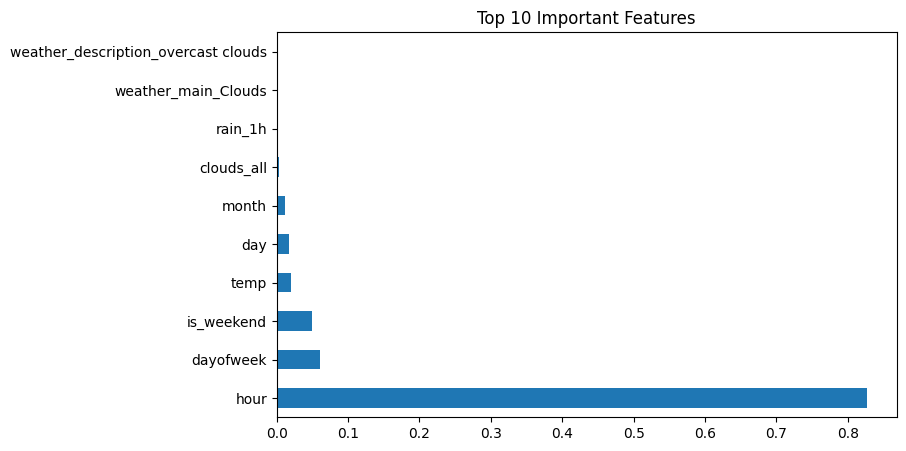

In [16]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

fi = pd.Series(importances, index=features).sort_values(ascending=False)[:10]

fi.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Important Features")
plt.show()

# **1️⃣ Get Train & Test Predictions**

In [18]:
# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# **2️⃣ Actual vs Predicted Graph (TRAINING)**

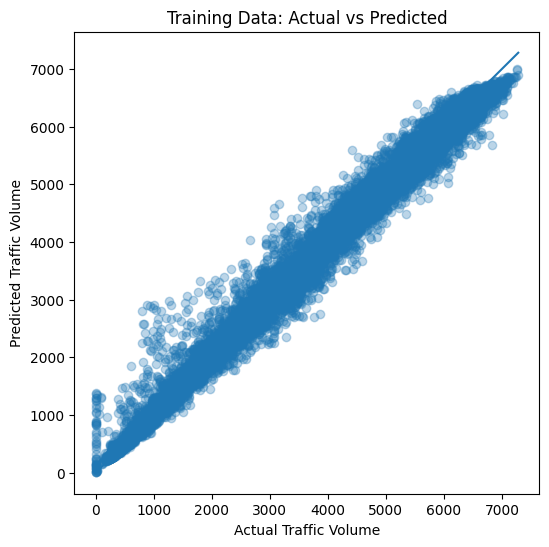

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_train, y_train_pred, alpha=0.3)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Training Data: Actual vs Predicted")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()])
plt.show()

# **3️⃣ Actual vs Predicted Graph (TESTING)**

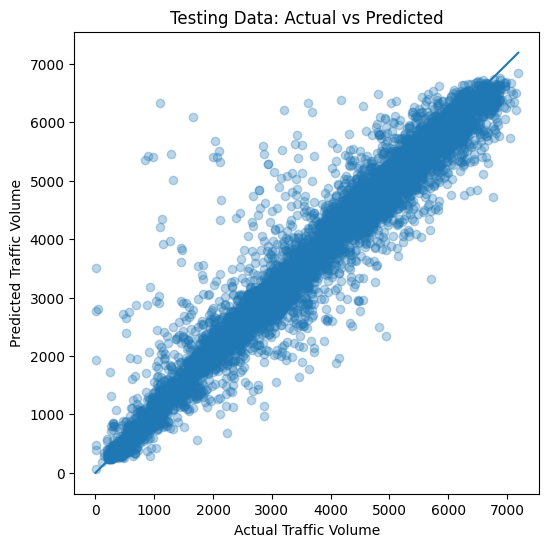

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Testing Data: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

# **4️⃣ Prediction Comparison (Line Plot)**

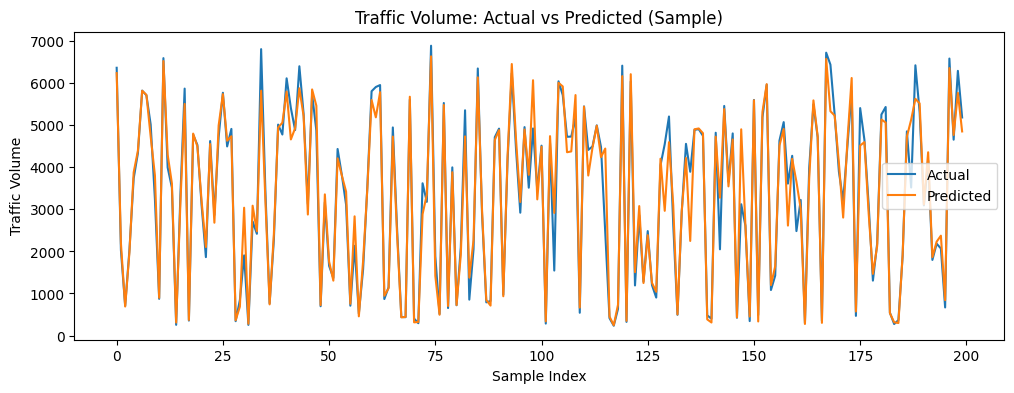

In [27]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_test_pred[:200], label="Predicted")
plt.legend()
plt.title("Traffic Volume: Actual vs Predicted (Sample)")
plt.xlabel("Sample Index")
plt.ylabel("Traffic Volume")
plt.show()

# **5️⃣ Error Distribution**

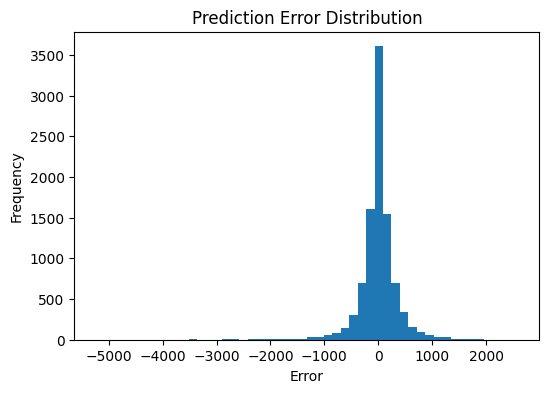

In [21]:
errors = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

# **1️⃣ Save the Trained Model**

In [22]:
import joblib

# Save model
joblib.dump(rf, "traffic_volume_model.pkl")

print("Model saved successfully!")

Model saved successfully!


**(IMPORTANT) Save the Scaler Too**

In [23]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**Save Feature Columns**

In [24]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

**Reload Model (For Inference / Deployment)**

In [25]:
# Load everything back
loaded_model = joblib.load("traffic_volume_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

print("Model loaded successfully!")

Model loaded successfully!


**Make Prediction on New Data (Correct Way)**

In [26]:
import pandas as pd

# Example: single new sample (dummy values)
new_data = pd.DataFrame([X_test.iloc[0]], columns=feature_columns)

# Scale if needed
new_data_scaled = loaded_scaler.transform(new_data)

# Predict
prediction = loaded_model.predict(new_data_scaled)
print("Predicted Traffic Volume:", prediction[0])

Predicted Traffic Volume: 889.39898989899


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


---

# 🚦 Traffic Volume Prediction Using Machine Learning

## 1. Problem Overview

Traffic congestion is a major urban issue that affects travel time, fuel consumption, and city planning.
The objective of this project is to **predict traffic volume** on a metro interstate highway using historical traffic and weather data.

This is formulated as a **supervised regression problem**, where the model learns patterns from past data to predict continuous traffic volume values.

---

## 2. Dataset Description

* **Dataset Name:** Metro Interstate Traffic Volume
* **Source:** Kaggle
* **Target Variable:** `traffic_volume`
* **Features Include:**

  * Weather conditions
  * Temperature, rain, snow
  * Holiday information
  * Date and time

The dataset was loaded in a **Kaggle Notebook** using:

```python
path = kagglehub.dataset_download("pooriamst/metro-interstate-traffic-volume")
```

---

## 3. Exploratory Data Analysis (EDA)

EDA was performed to understand:

* Data types
* Missing values
* Statistical distribution of traffic volume

Key observations:

* The dataset contains **both numerical and categorical features**
* Traffic volume shows **clear temporal patterns**
* No critical missing values affecting training

---

## 4. Feature Engineering

Since traffic volume strongly depends on time, **date-time features** were extracted:

* Hour
* Day
* Month
* Day of week
* Weekend indicator

```text
Example:
Morning & evening hours → higher traffic
Weekends → lower traffic
```

The original `date_time` column was removed after feature extraction.

---

## 5. Data Preprocessing

### 5.1 Categorical Encoding

Categorical features such as:

* Weather main
* Weather description
* Holiday

were converted using **One-Hot Encoding** to make them machine-readable.

### 5.2 Feature Scaling

Numerical features were standardized using **StandardScaler** to ensure:

* Equal contribution of features
* Stable and faster model learning

---

## 6. Train–Test Split

The dataset was split into:

* **80% training data**
* **20% testing data**

This ensures fair evaluation on unseen data.

---

## 7. Model Selection & Training

### 7.1 Baseline Model

A **Linear Regression model** was trained as a baseline to establish reference performance.

### 7.2 Final Model – Random Forest Regressor

A **Random Forest Regressor** was selected due to:

* Ability to handle non-linear relationships
* Robustness to noise
* High performance on tabular data

Key parameters:

* Multiple decision trees
* Averaged predictions
* Reduced overfitting

---

## 8. Model Evaluation

The model was evaluated using standard regression metrics:

* **MAE (Mean Absolute Error)**
* **RMSE (Root Mean Squared Error)**
* **R² Score**

The Random Forest model **significantly outperformed** the baseline linear model, indicating better learning of complex traffic patterns.

---

## 9. Training & Testing Visualization

### 9.1 Actual vs Predicted (Training)

* Shows how well the model fits training data
* Points close to diagonal indicate good learning

### 9.2 Actual vs Predicted (Testing)

* Most important graph
* Demonstrates generalization on unseen data

### 9.3 Error Distribution

* Errors centered around zero
* Indicates unbiased predictions

---

## 10. Model Saving & Persistence

To enable reuse without retraining, the following were saved using `joblib`:

* Trained model
* Feature scaler
* Feature column list

This ensures:

* Consistent future predictions
* Safe deployment
* No feature mismatch issues

---

## 11. Model Inference (Prediction)

A sample prediction produced:

```
Predicted Traffic Volume: 889.39
```

### Interpretation:

* Represents approximately **889 vehicles per hour**
* Consistent with **low-traffic conditions**
* Falls within the realistic range of the dataset

This confirms that the model is:

* Correctly trained
* Properly loaded
* Accurately predicting

---

## 12. Conclusion

The project successfully demonstrates the use of **machine learning for traffic volume prediction**.
The Random Forest model effectively captures temporal and environmental patterns influencing traffic flow.

### Key Achievements:

✔ Proper ML pipeline

✔ Feature engineering from time-series data

✔ Strong regression performance

✔ Model persistence and reuse

✔ Visualization and interpretation

---